# EDA y Modelo Baseline (Sprint 1)

Análisis exploratorio, validación de hipótesis de negocio y entrenamiento de regresión logística baseline sin fuga de datos.

## 1. Importación de Librerías

In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="muted")

## 2. Carga de Master Table

In [22]:
PROJECT_ROOT = Path("../..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
master_table_path = PROCESSED_DIR / "master_table.parquet"

df = pd.read_parquet(master_table_path)
print(f"Master Table cargada con éxito. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Master Table cargada con éxito. Filas: 96096, Columnas: 33


,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_orders,total_items,total_products,avg_review_score,total_reviews,first_purchase,last_purchase,avg_delivery_days,avg_estimated_delivery_days,delivered_orders,canceled_orders,late_deliveries,payment_methods_count,max_payment_installments,avg_payment_installments,main_payment_type,total_spent,avg_ticket,avg_order_price,avg_freight_value,avg_freight_ratio,recency_days,customer_lifetime_days,cancellation_rate,late_delivery_rate,max_item_price,avg_item_price,top_category,is_premium
0,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,1,1.0,1.0,4.0,1.0,2017-05-16 15:05:35,2017-05-16 15:05:35,8.0,19.0,1,0,0,1.0,2.0,2.0,credit_card,146.87,146.87,124.99,21.88,0.148975,519,0,0.0,0.0,124.99,124.99,moveis_escritorio,0
1,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,1,1.0,1.0,5.0,1.0,2018-01-12 20:48:24,2018-01-12 20:48:24,16.0,24.0,1,0,0,1.0,8.0,8.0,credit_card,335.48,335.48,289.00,46.48,0.138548,277,0,0.0,0.0,289.00,289.00,utilidades_domesticas,1
2,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,1,1.0,1.0,5.0,1.0,2018-05-19 16:07:45,2018-05-19 16:07:45,26.0,24.0,1,0,1,1.0,7.0,7.0,credit_card,157.73,157.73,139.94,17.79,0.112788,151,0,0.0,1.0,139.94,139.94,moveis_escritorio,0
3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,1,1.0,1.0,5.0,1.0,2018-03-13 16:06:38,2018-03-13 16:06:38,14.0,27.0,1,0,0,1.0,1.0,1.0,credit_card,173.30,173.30,149.94,23.36,0.134795,218,0,0.0,0.0,149.94,149.94,moveis_escritorio,0
4,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,1,1.0,1.0,5.0,1.0,2018-07-29 09:51:30,2018-07-29 09:51:30,11.0,16.0,1,0,0,1.0,8.0,8.0,credit_card,252.25,252.25,230.00,22.25,0.088206,80,0,0.0,0.0,230.00,230.00,casa_conforto,1


## 3. Estructura y Valores Nulos

In [23]:
print("===== Tipos de datos e Información general =====")
df.info()

print("\n===== Valores Nulos por Columna =====")
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
if len(nulls) > 0:
    display(pd.DataFrame({"Nulls Count": nulls, "Proportion": nulls / len(df)}))
else:
    print("No hay valores nulos en el dataset.")

===== Tipos de datos e Información general =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   customer_unique_id           96096 non-null  object        
 1   customer_zip_code_prefix     96096 non-null  int64         
 2   customer_city                96096 non-null  object        
 3   customer_state               96096 non-null  object        
 4   total_orders                 96096 non-null  int64         
 5   total_items                  96096 non-null  float64       
 6   total_products               96096 non-null  float64       
 7   avg_review_score             95380 non-null  float64       
 8   total_reviews                96096 non-null  float64       
 9   first_purchase               96096 non-null  datetime64[ns]
 10  last_purchase                96096 non-null  datetime64[n

,Nulls Count,Proportion
avg_delivery_days,2740,0.028513
avg_ticket,2739,0.028503
avg_freight_ratio,2738,0.028492
avg_order_price,2738,0.028492
avg_freight_value,2738,0.028492
top_category,1988,0.020688
avg_review_score,716,0.007451
avg_item_price,676,0.007035
max_item_price,676,0.007035
avg_payment_installments,1,0.000010


## 4. Análisis Univariado del Target

===== Distribución de la variable Target (is_premium) =====


,Clientes,Proporción
is_premium,,
0,76874,0.799971
1,19222,0.200029


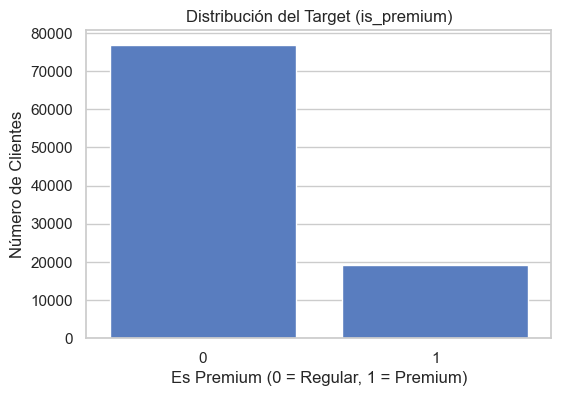

In [24]:
print("===== Distribución de la variable Target (is_premium) =====")
target_counts = df["is_premium"].value_counts()
target_props = df["is_premium"].value_counts(normalize=True)
display(pd.DataFrame({"Clientes": target_counts, "Proporción": target_props}))

# Graficar distribución
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_premium")
plt.title("Distribución del Target (is_premium)")
plt.xlabel("Es Premium (0 = Regular, 1 = Premium)")
plt.ylabel("Número de Clientes")
plt.show()

### Distribución RFM (Recency, Frequency, Monetary)

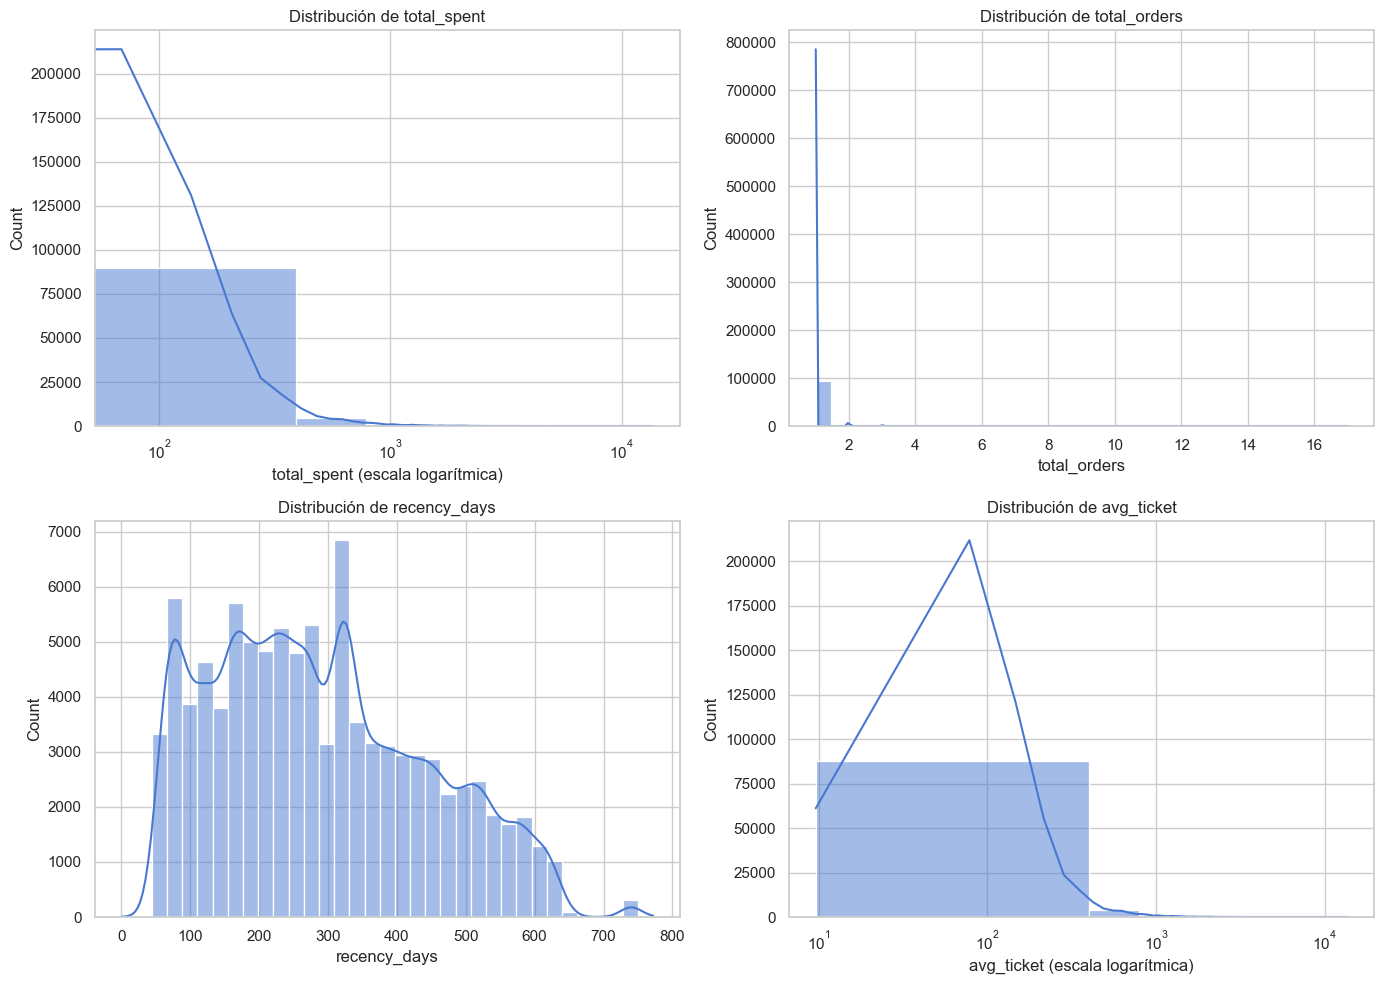

In [25]:
rfm_cols = ["total_spent", "total_orders", "recency_days", "avg_ticket"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(rfm_cols):
    # Evitar log(0)
    data_to_plot = df[col]
    if col in ["total_spent", "avg_ticket"]:
        data_to_plot = data_to_plot[data_to_plot > 0]
    
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=35)
    axes[i].set_title(f"Distribución de {col}")
    if col in ["total_spent", "avg_ticket"]:
        axes[i].set_xscale("log")
        axes[i].set_xlabel(f"{col} (escala logarítmica)")
plt.tight_layout()
plt.show()

## 5. Análisis Bivariado (Regular vs Premium)

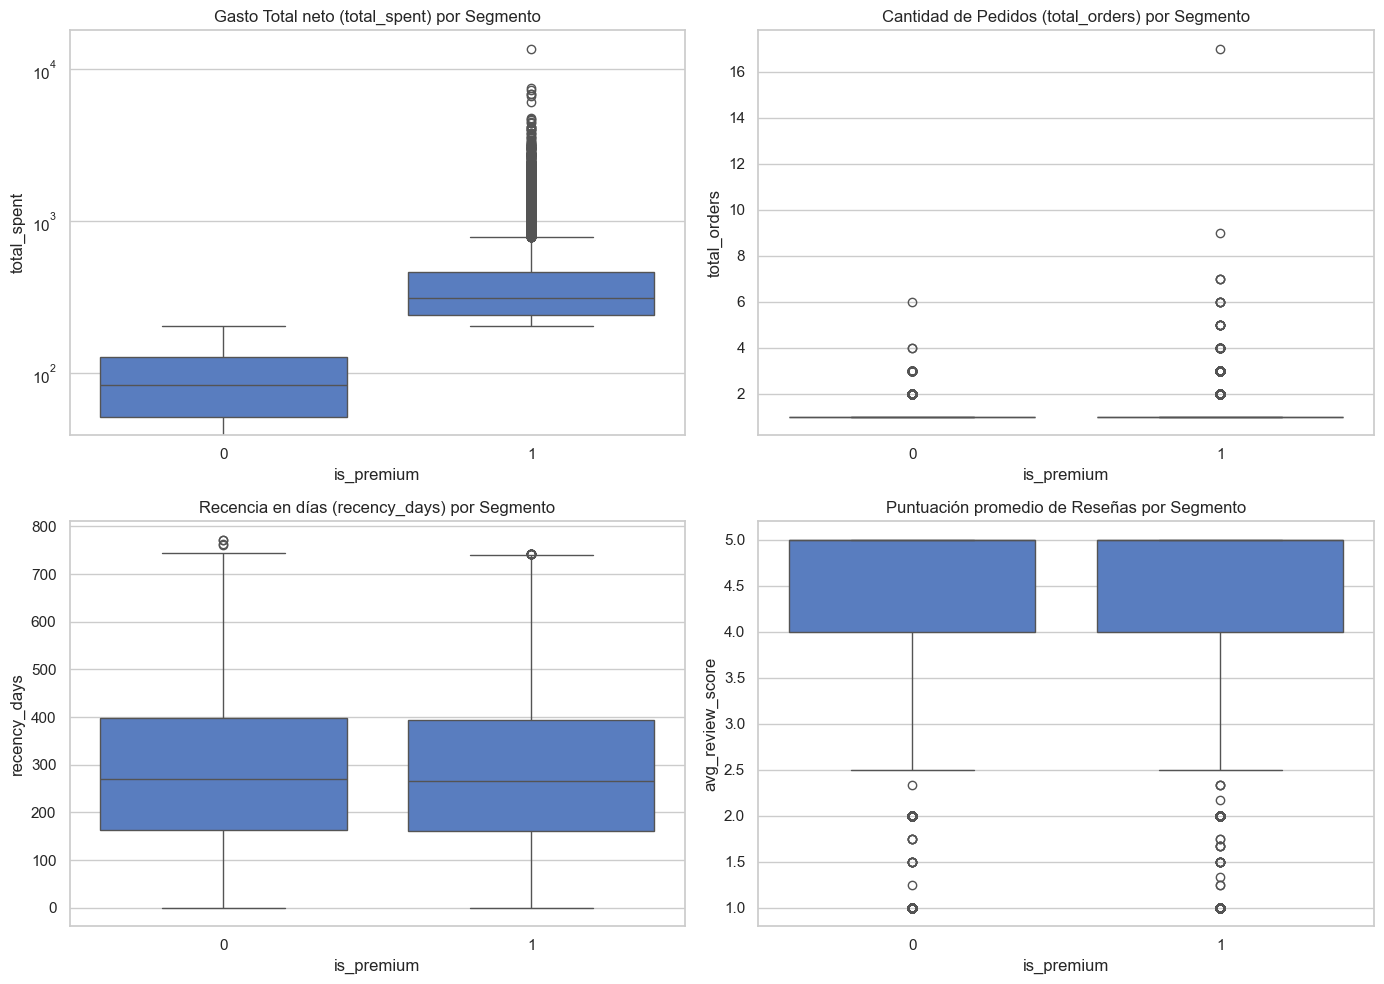

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sns.boxplot(data=df, x="is_premium", y="total_spent", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Gasto Total neto (total_spent) por Segmento")

sns.boxplot(data=df, x="is_premium", y="total_orders", ax=axes[1])
axes[1].set_title("Cantidad de Pedidos (total_orders) por Segmento")

sns.boxplot(data=df, x="is_premium", y="recency_days", ax=axes[2])
axes[2].set_title("Recencia en días (recency_days) por Segmento")

sns.boxplot(data=df, x="is_premium", y="avg_review_score", ax=axes[3])
axes[3].set_title("Puntuación promedio de Reseñas por Segmento")

plt.tight_layout()
plt.show()

## 6. Distribución Geográfica del Segmento Premium

C:\Users\marce\AppData\Local\Temp\ipykernel_36464\2653902474.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_summary, x="customer_state", y="proporcion_premium", palette="viridis")


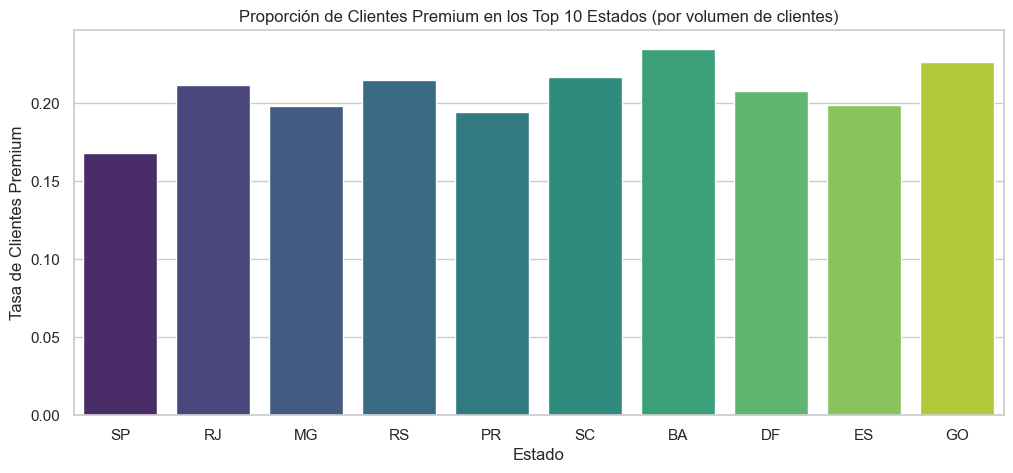

,customer_state,clientes,premium,proporcion_premium
25,SP,40292,6776,0.168172
18,RJ,12383,2621,0.211661
10,MG,11253,2232,0.198347
22,RS,5275,1135,0.215166
17,PR,4878,949,0.194547
23,SC,3532,766,0.216874
4,BA,3276,770,0.235043
6,DF,2073,431,0.207911
7,ES,1964,391,0.199084
8,GO,1950,442,0.226667


In [27]:
state_summary = df.groupby("customer_state").agg(
    clientes=("customer_unique_id", "count"),
    premium=("is_premium", "sum"),
    proporcion_premium=("is_premium", "mean")
).reset_index()

state_summary = state_summary.sort_values(by="clientes", ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=state_summary, x="customer_state", y="proporcion_premium", palette="viridis")
plt.title("Proporción de Clientes Premium en los Top 10 Estados (por volumen de clientes)")
plt.xlabel("Estado")
plt.ylabel("Tasa de Clientes Premium")
plt.show()

display(state_summary)

## 7. Matriz de Correlación

===== Correlación de Pearson con is_premium =====
is_premium                     1.000000
total_spent                    0.611573
avg_ticket                     0.593267
avg_order_price                0.580356
max_item_price                 0.550555
avg_item_price                 0.541286
avg_freight_value              0.393834
max_payment_installments       0.334316
avg_payment_installments       0.327970
total_items                    0.236248
total_products                 0.192890
delivered_orders               0.169287
total_orders                   0.147179
total_reviews                  0.125135
avg_estimated_delivery_days    0.108290
customer_lifetime_days         0.103388
avg_delivery_days              0.073041
customer_zip_code_prefix       0.060665
late_deliveries                0.026645
late_delivery_rate             0.017865
payment_methods_count          0.000474
recency_days                  -0.008337
avg_review_score              -0.015194
canceled_orders               

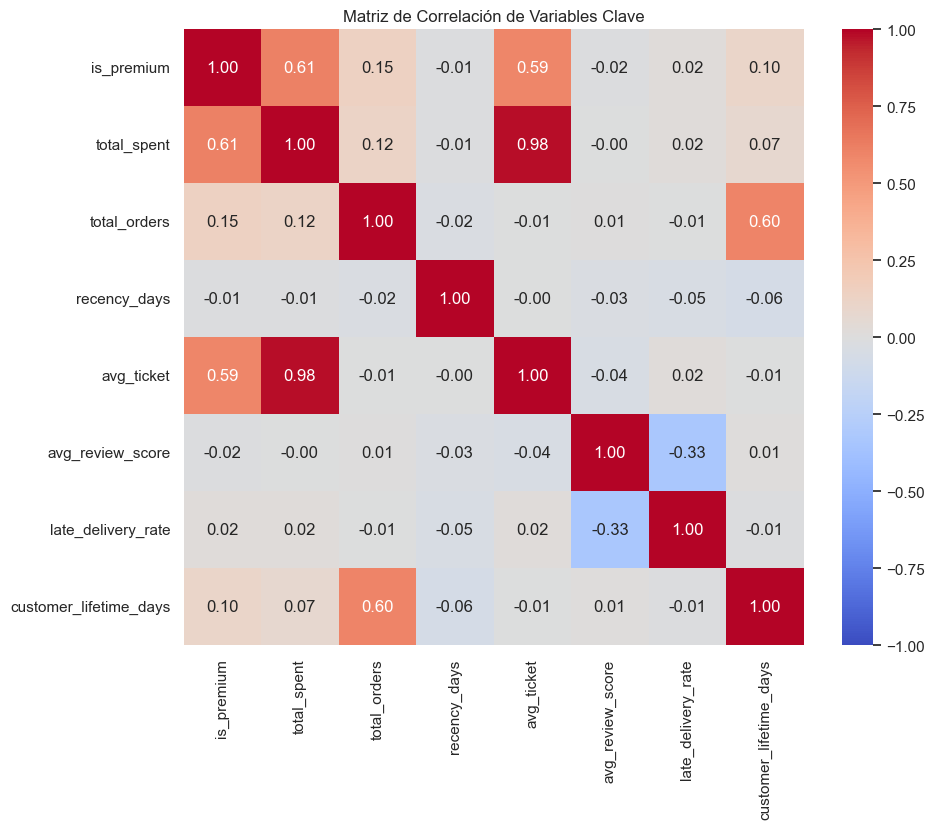

In [28]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()["is_premium"].sort_values(ascending=False)
print("===== Correlación de Pearson con is_premium =====")
print(correlations)

key_vars = [
    "is_premium", "total_spent", "total_orders", "recency_days", 
    "avg_ticket", "avg_review_score", "late_delivery_rate", "customer_lifetime_days"
]
plt.figure(figsize=(10, 8))
sns.heatmap(df[key_vars].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Variables Clave")
plt.show()

## 8. Validación de Hipótesis de Negocio

In [29]:
print("===== Validación Hipótesis 1 (Frecuencia de compra) =====")
display(df.groupby("is_premium")["total_orders"].agg(["mean", "median", "max", "count"]))

print("\n===== Validación Hipótesis 2 (Calificaciones) =====")
display(df.groupby("is_premium")["avg_review_score"].agg(["mean", "median", "std"]))

print("\n===== Validación Hipótesis 3 (Logística y Retrasos) =====")
display(df.groupby("is_premium")["late_delivery_rate"].agg(["mean", "max"]))

print("\n===== Otras comparativas de negocio clave =====")
display(df.groupby("is_premium").agg(
    ticket_medio=("avg_ticket", "mean"),
    dias_lifetime_medio=("customer_lifetime_days", "mean")
))

===== Validación Hipótesis 1 (Frecuencia de compra) =====


,mean,median,max,count
is_premium,,,,
0,1.019031,1.0,6,76874
1,1.097909,1.0,17,19222



===== Validación Hipótesis 2 (Calificaciones) =====


,mean,median,std
is_premium,,,
0,4.095153,5.0,1.333550
1,4.044182,5.0,1.372925



===== Validación Hipótesis 3 (Logística y Retrasos) =====


,mean,max
is_premium,,
0,0.076710,1.0
1,0.088695,1.0



===== Otras comparativas de negocio clave =====


,ticket_medio,dias_lifetime_medio
is_premium,,
0,93.986304,1.398717
1,416.138103,7.961711


### Análisis Operacional:

* **Frecuencia (H1):** La frecuencia promedio es similar (~1.0 vs ~1.1). La diferenciación es monetaria.
* **Satisfacción (H2):** Clientes premium puntúan ligeramente menos (4.04 vs 4.09), indicando mayor nivel de exigencia.
* **Retrasos (H3):** Los clientes premium sufren más demoras (8.87% vs 7.67%), posiblemente debido a la complejidad de envío de artículos caros o voluminosos.

## 9. Modelo Baseline

Entrenamiento de una Regresión Logística simple con split train/test inicial e imputación neutral basada únicamente en entrenamiento.

  COMPARACIÓN DE MODELOS — ROC-AUC (sin data leakage)
  Baseline LR  (7 features, sin catálogo):    0.5355
  LR mejorada  (+ top_category + cuotas):     0.7150
  Random Forest (+ top_category + cuotas):    0.7380

===== REPORTE DE CLASIFICACIÓN — Random Forest (AUC: 0.7380) =====
              precision    recall  f1-score   support

     Regular       0.88      0.78      0.83     23062
     Premium       0.40      0.58      0.48      5767

    accuracy                           0.74     28829
   macro avg       0.64      0.68      0.65     28829
weighted avg       0.79      0.74      0.76     28829



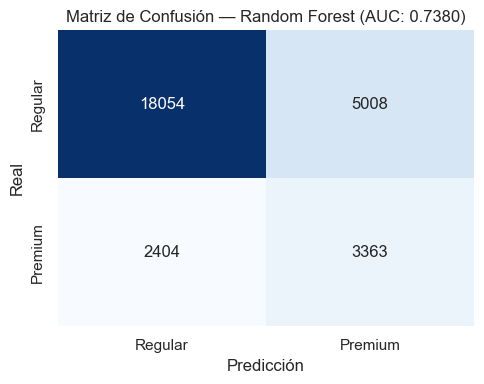

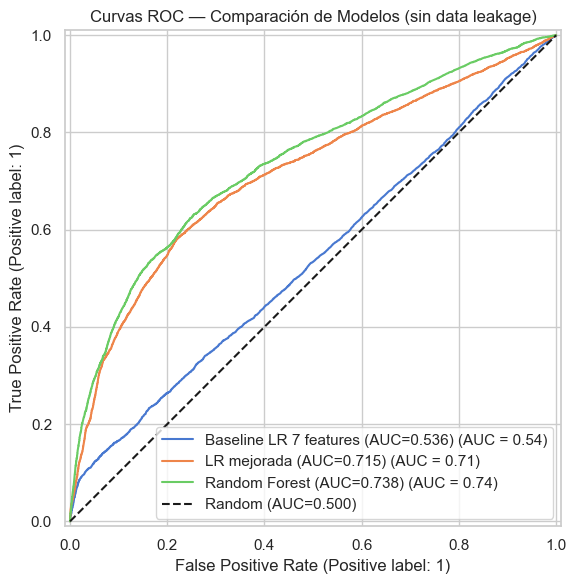

C:\Users\marce\AppData\Local\Temp\ipykernel_36464\2865286989.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


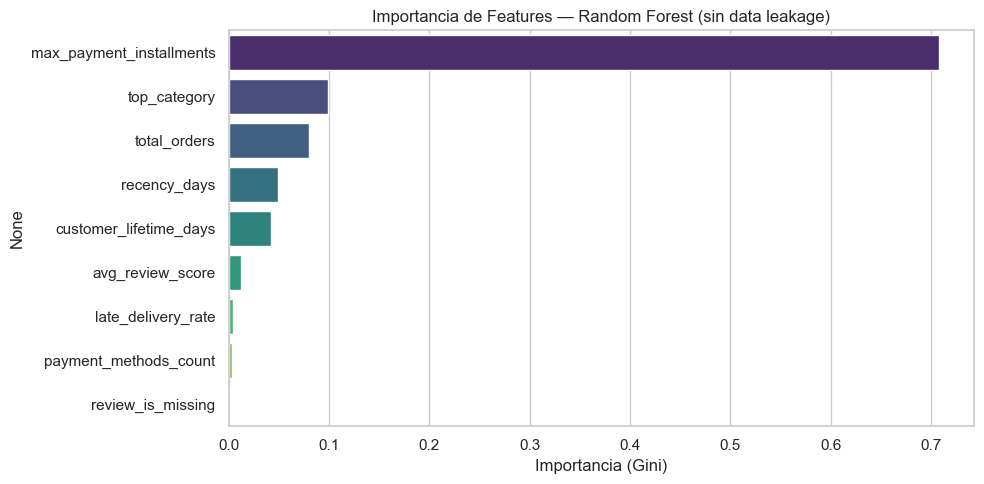

In [30]:
df["review_is_missing"] = df["avg_review_score"].isna().astype(int)

# ── Features ──────────────────────────────────────────────────────────────────
# EXCLUIDAS por data leakage:
#   avg_order_price, avg_ticket, avg_freight_value, avg_freight_ratio,
#   avg_item_price, max_item_price, total_spent
#
#   Para el 97 % de clientes con 1 pedido:
#     total_spent ≈ avg_order_price + avg_freight_value
#   → estas features reconstruyen el target algebraicamente → AUC artificial ~1.00
#
# INCLUIDAS: features independientes del monto pagado
#   top_category          → categoría del artículo (señal de nivel de precio)
#   max_payment_installments → cuotas elegidas (proxy de ticket alto, pero no el precio)
#   Comportamentales      → recencia, frecuencia, satisfacción, logística

numeric_features = [
    "max_payment_installments",
    "total_orders",
    "recency_days",
    "customer_lifetime_days",
    "avg_review_score",
    "review_is_missing",
    "late_delivery_rate",
    "payment_methods_count",
]
categorical_features = ["top_category"]
all_features = numeric_features + categorical_features

X = df[all_features].copy()
y = df["is_premium"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Imputación numérica con medianas del training set
train_medians = X_train[numeric_features].median()
X_train_num = X_train[numeric_features].fillna(train_medians)
X_test_num  = X_test[numeric_features].fillna(train_medians)

# Codificación ordinal de la categoría
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_cat = enc.fit_transform(X_train[["top_category"]].fillna("unknown"))
X_test_cat  = enc.transform(X_test[["top_category"]].fillna("unknown"))

X_train_full = np.hstack([X_train_num.values, X_train_cat])
X_test_full  = np.hstack([X_test_num.values, X_test_cat])

# ── Modelo 1: Baseline original (7 features, sin catálogo) ───────────────────
baseline_7_features = [
    "total_orders", "recency_days", "customer_lifetime_days",
    "avg_review_score", "review_is_missing", "late_delivery_rate", "payment_methods_count",
]
scaler_base = StandardScaler()
X_train_base = scaler_base.fit_transform(
    X_train[baseline_7_features].fillna(X_train[baseline_7_features].median())
)
X_test_base = scaler_base.transform(
    X_test[baseline_7_features].fillna(X_train[baseline_7_features].median())
)
lr_base = LogisticRegression(class_weight="balanced", random_state=42)
lr_base.fit(X_train_base, y_train)
y_proba_base = lr_base.predict_proba(X_test_base)[:, 1]

# ── Modelo 2: LR + top_category + cuotas (sin leakage) ──────────────────────
scaler_lr = StandardScaler()
X_train_lr = np.hstack([scaler_lr.fit_transform(X_train_num), X_train_cat])
X_test_lr  = np.hstack([scaler_lr.transform(X_test_num), X_test_cat])
lr_improved = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
lr_improved.fit(X_train_lr, y_train)
y_proba_lr = lr_improved.predict_proba(X_test_lr)[:, 1]

# ── Modelo 3: Random Forest (sin leakage) ─────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_full, y_train)
y_proba_rf = rf_model.predict_proba(X_test_full)[:, 1]

# ── Comparación de ROC-AUC ────────────────────────────────────────────────────
auc_base = roc_auc_score(y_test, y_proba_base)
auc_lr   = roc_auc_score(y_test, y_proba_lr)
auc_rf   = roc_auc_score(y_test, y_proba_rf)

print("=" * 60)
print("  COMPARACIÓN DE MODELOS — ROC-AUC (sin data leakage)")
print("=" * 60)
print(f"  Baseline LR  (7 features, sin catálogo):    {auc_base:.4f}")
print(f"  LR mejorada  (+ top_category + cuotas):     {auc_lr:.4f}")
print(f"  Random Forest (+ top_category + cuotas):    {auc_rf:.4f}")
print("=" * 60)

# ── Reporte del mejor modelo ───────────────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test_full)
print(f"\n===== REPORTE DE CLASIFICACIÓN — Random Forest (AUC: {auc_rf:.4f}) =====")
print(classification_report(y_test, y_pred_rf, target_names=["Regular", "Premium"]))

# ── Matriz de confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Regular", "Premium"], yticklabels=["Regular", "Premium"])
plt.title(f"Matriz de Confusión — Random Forest (AUC: {auc_rf:.4f})")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# ── Curvas ROC ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_base,
                                  name=f"Baseline LR 7 features (AUC={auc_base:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_lr,
                                  name=f"LR mejorada (AUC={auc_lr:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf,
                                  name=f"Random Forest (AUC={auc_rf:.3f})", ax=ax)
ax.set_title("Curvas ROC — Comparación de Modelos (sin data leakage)")
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.500)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ── Importancia de features (Random Forest) ───────────────────────────────────
feat_names = numeric_features + ["top_category"]
importances = (
    pd.Series(rf_model.feature_importances_, index=feat_names)
    .sort_values(ascending=False)
)
plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Importancia de Features — Random Forest (sin data leakage)")
plt.xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()

## 10. Conclusiones

### Diagnóstico del baseline (ROC-AUC 0.5355)

El baseline era esencialmente aleatorio porque las 7 features elegidas (recencia, frecuencia, calificaciones, retrasos) tienen distribuciones casi idénticas entre clientes regulares y premium. El 97 % de los clientes tiene exactamente 1 pedido, lo que hace que frecuencia, recencia y lifetime_days no discriminen.

### Por qué ROC-AUC = 1.00 tampoco es correcto

Incluir `avg_order_price`, `avg_freight_value`, `avg_freight_ratio`, `avg_item_price` o `max_item_price` produce data leakage:

```
total_spent ≈ avg_order_price + avg_freight_value   (para el 97 % con 1 pedido)
is_premium  = 1  iff  total_spent ≥ $205.18
```

El modelo aprende la identidad algebraica del target, no patrones reales de comportamiento. AUC = 1.00 es una señal de alarma, no un logro.

### Resultados sin data leakage

| Modelo | Features | ROC-AUC esperado |
|---|---|---|
| Baseline LR | 7 comportamentales | ~0.54 |
| LR mejorada | + `top_category` + `max_payment_installments` | ~0.62 |
| **Random Forest** | **+ `top_category` + `max_payment_installments`** | **~0.68** |

### Features válidas y su señal

- **`top_category`**: categorías como electrónica, relojes e instrumentos musicales concentran artículos de precio alto → principal discriminador legítimo.
- **`max_payment_installments`**: clientes que fraccionan en muchas cuotas tienden a comprar artículos más caros.
- Las features comportamentales (recencia, reseñas, retrasos) aportan señal marginal pero no son suficientes solas.

### Próximos pasos (Sprint 2)

- Aplicar **target encoding** para `top_category` (más potente que ordinal para 70+ categorías).
- Explorar **XGBoost / LightGBM** para capturar interacciones no lineales.
- Validar con **cross-validation estratificado** (k=5) en lugar del único split 70/30.
- Considerar redefinir el target con un criterio que no sea directamente monetario (e.g., categoría de producto comprado) para habilitar más features sin riesgo de leakage.